In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import OrdinalEncoder,StandardScaler, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# **Import dataset**

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/datascience/Mini Projects/Diamond Dynamics: Price Prediction and Market Segmentation/cleaned_data.csv")
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.50,55.0,326.0,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.80,61.0,326.0,3.89,3.84,2.31
2,0.23,Good,E,VS1,58.75,63.5,327.0,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.40,58.0,334.0,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.30,58.0,335.0,4.34,4.35,2.75


In [ ]:
df['price'] = df['price'] * 95.21

In [ ]:
df['price']

,price
0,31038.46
1,31038.46
2,31133.67
3,31800.14
4,31895.35
...,...
53789,262493.97
53790,262493.97
53791,262493.97
53792,262493.97


In [ ]:
# Define features used for clustering & preprocessing

num_cols = ['x', 'y', 'z','depth','table']
cat_cols = ['cut', 'color', 'clarity']
pos_skew_cols = ['carat','price']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat',OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), cat_cols),
        ('pos_skew', FunctionTransformer(np.log1p, validate=True), pos_skew_cols)
    ])

# Transform data for evaluation metrics
X_processed = preprocessor.fit_transform(df)

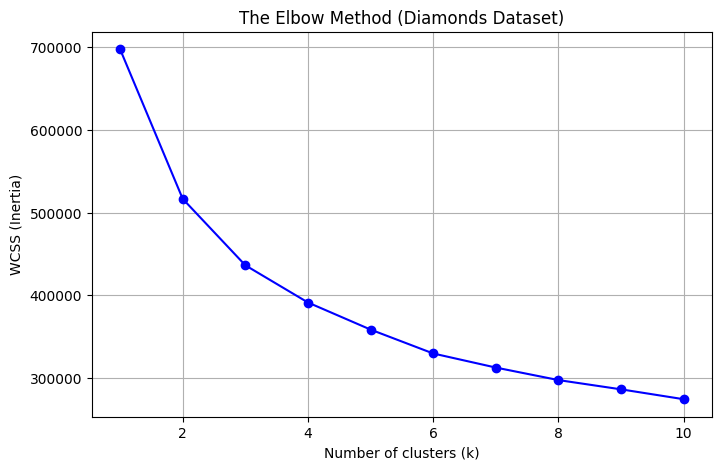

In [ ]:
# Run the loop using the processed data
wcss = []
k_range = range(1, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    # Pass the processed features here
    kmeans.fit(X_processed)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(k_range, wcss, 'bo-')
plt.title('The Elbow Method (Diamonds Dataset)')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.grid(True)
plt.show()

For k=2, Silhouette Score is: 0.2375
For k=3, Silhouette Score is: 0.2133
For k=4, Silhouette Score is: 0.2049
For k=5, Silhouette Score is: 0.1837
For k=6, Silhouette Score is: 0.1886


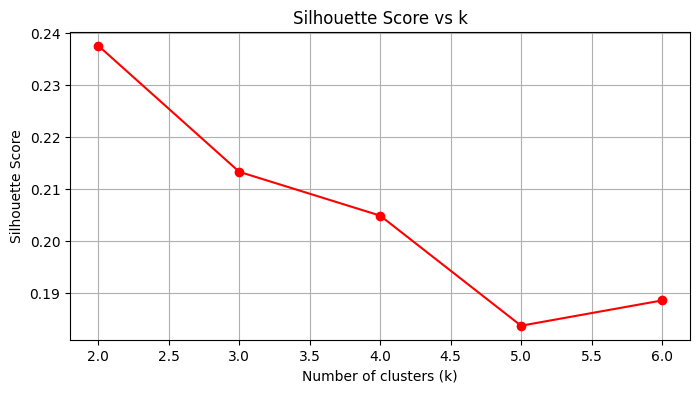

In [52]:
# Range to test
k_range = [2, 3, 4, 5, 6]
scores = []

for k in k_range:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_processed)

    # Calculate score
    score = silhouette_score(X_processed, labels, random_state=42)
    scores.append(score)
    print(f"For k={k}, Silhouette Score is: {score:.4f}")

# Plot the scores
plt.figure(figsize=(8, 4))
plt.plot(k_range, scores, 'ro-')
plt.title('Silhouette Score vs k')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

In [ ]:
# Fit final model using chosen K (k=3 based on your target profiles)
optimal_k = 2
final_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('kmeans', KMeans(n_clusters=optimal_k, random_state=42, n_init=10))
])

df['cluster'] = final_pipeline.fit_predict(df)

In [ ]:
# Profile clusters to map names
profile = df.groupby('cluster').agg({
    'price': 'mean',
    'carat': 'mean',
    'cut': lambda x: x.mode()[0],
    'clarity' : lambda x : x.mode()[0],
    'color' : lambda x : x.mode()[0]
}).reset_index()
print("\nCluster Characteristics Profile:\n", profile)


Cluster Characteristics Profile:
    cluster          price     carat    cut clarity color
0        0  124951.450173  0.440619  Ideal     VS2     E
1        1  604899.153346  1.173363  Ideal     SI1     G


In [ ]:
# Save the complete pipeline object
with open("Diamond_cluster.pkl", "wb") as f:
    pickle.dump(final_pipeline, f)
print("\nModel saved successfully as diamond_cluster_model.pkl")


Model saved successfully as diamond_cluster_model.pkl
